In [4]:
!pip install -q -U google-genai pydantic python-dotenv tabulate

In [5]:
# CELL 0: ENVIRONMENT SETUP & SECURE API AUTHENTICATION
# Run this cell first. Installs the Google GenAI SDK, Pydantic, and dotenv.


import os
import sys
import time
import json
import random
import getpass
from typing import List, Dict, Any, Optional
from pydantic import BaseModel, Field

# Official Google GenAI SDK
from google import genai
from google.genai import types
from google.genai.errors import APIError


# Secure Gemini API Key Ingestion (Zero-Hardcoding Policy)

# Never hardcode API keys directly in scripts!
# In Google Colab, use the Secrets Manager (🔑 icon on the left panel) as 'GEMINI_API_KEY'.
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
except Exception:
    GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')

if not GEMINI_API_KEY:
    GEMINI_API_KEY = getpass.getpass("🔑 Enter your Google Gemini API Key: ")
    os.environ['GEMINI_API_KEY'] = GEMINI_API_KEY

# Initialize Client
client = genai.Client(api_key=GEMINI_API_KEY)
print("✅ Google Gemini API Client initialized successfully!")

✅ Google Gemini API Client initialized successfully!


### SECTION 1: API ARCHITECTURE, STATELESSNESS & SECURITY HYGIENE

1. WHY API KEYS MUST NEVER BE COMMITTED TO GITHUB:
   - Automated scrapers search public GitHub commits 24/7 for exposed API keys.
   - Leaked keys result in quota exhaustion, unexpected billing charges, and credential revocation.
   - DEFENSE: Store keys in a local `.env` file and add `.env` to `.gitignore`.

2. THE STATELESSNESS MENTAL MODEL:
   - LLMs are 100% STATELESS: The model remembers NOTHING between individual API calls.
   - To build a conversational multi-turn chatbot, YOU (the developer) must maintain a history list
     of previous (User, Model) turns and pass the cumulative array on every subsequent call.

3. MESSAGE ROLES MAPPING:
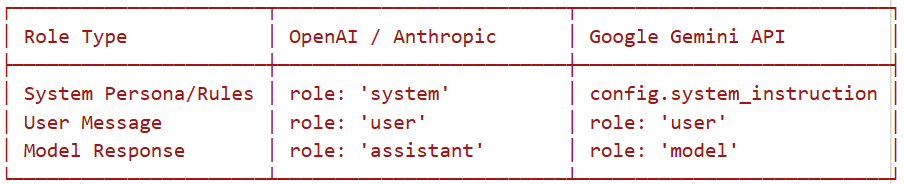

### SECTION 2: PRE-FLIGHT TOKEN COUNTING & FINANCIAL COST ESTIMATION (UPDATED)

COST ESTIMATION BEST PRACTICE:  
Count input tokens BEFORE invoking expensive generation calls to protect budget thresholds.


In [6]:
import numpy as np
def preflight_cost_estimate(
    text_prompt: str,
    model_name: str = "gemini-3.6-flash",
    expected_output_tokens: int = 500
) -> Dict[str, Any]:
    """Calculates exact input tokens and estimates financial cost before calling the API."""
    # Count tokens using official Gemini Tokenizer
    token_resp = client.models.count_tokens(model=model_name, contents=text_prompt)
    input_tokens = token_resp.total_tokens

    # Official Rates per 1M tokens (USD)
    pricing = {
        "gemini-3.6-flash": {"in": 0.075, "out": 0.30},
        "gemini-1.5-pro":   {"in": 1.25,  "out": 5.00}
    }
    rate = pricing.get(model_name, pricing["gemini-3.6-flash"])

    est_cost = (input_tokens / 1e6 * rate["in"]) + (expected_output_tokens / 1e6 * rate["out"])

    return {
        "model": model_name,
        "input_tokens": input_tokens,
        "estimated_output_tokens": expected_output_tokens,
        "estimated_cost_usd": np.round(est_cost, 6),
        "cost_per_10k_calls": np.round(est_cost * 10000, 2)
    }

sample_payload = "Please summarize the last 10 quarterly financial filings of Apple, Microsoft, and Google."
# Updated to gemini-3.6-flash
estimate = preflight_cost_estimate(sample_payload, model_name="gemini-3.6-flash")
print("=== 📊 PRE-FLIGHT TOKEN & COST AUDIT ===")
for k, v in estimate.items():
    print(f"• {k:25s}: {v}")

=== 📊 PRE-FLIGHT TOKEN & COST AUDIT ===
• model                    : gemini-3.6-flash
• input_tokens             : 19
• estimated_output_tokens  : 500
• estimated_cost_usd       : 0.000151
• cost_per_10k_calls       : 1.51


### SECTION 3: PRODUCTION RESILIENCE — EXPONENTIAL BACKOFF & RETRY LOOP

HANDLING API FAILURES IN PRODUCTION:
1. Rate Limits (HTTP 429 / ResourceExhausted): Hit requests-per-minute (RPM) ceiling.
2. Transient Server Errors (HTTP 500 / 503): Temporary Google Cloud infrastructure hiccup.
3. Network Timeouts: Connection dropped during streaming.

REMEDY: EXPONENTIAL BACKOFF WITH JITTER:
Wait time = (base_delay * 2^attempt) + random_jitter
Prevents "Thundering Herd" problem where all failed clients retry at the exact same millisecond.


In [7]:
def execute_with_exponential_backoff(
    api_call_func,
    max_retries: int = 4,
    base_delay: float = 1.5
):
    """Wraps an API call in an exponential backoff retry loop with random jitter."""
    for attempt in range(max_retries):
        try:
            return api_call_func()
        except APIError as e:
            if attempt == max_retries - 1:
                print(f"❌ Max retries reached. Fatal API Error: {e}")
                raise e
            # Calculate backoff delay with jitter
            delay = (base_delay * (2 ** attempt)) + random.uniform(0.1, 0.8)
            print(f"⚠️ Warning: Transient API Error ({e.code}). Retrying in {delay:.2f}s... (Attempt {attempt+1}/{max_retries})")
            time.sleep(delay)

### SECTION 4: REUSABLE GEMINI WRAPPER & 3-TURN CHAT

In [8]:
# Construct a reusable production function supporting:
# - Streaming responses (Low Time-To-First-Token)
# - System instructions
# - Dynamic temperature
# - Exponential backoff retry logic

def gemini_call(
    prompt: str,
    system_instruction: str = "You are a concise, helpful enterprise AI assistant.",
    temperature: float = 0.2,
    stream: bool = False,
    model: str = "gemini-3.6-flash"
) -> str:
    """Production-grade wrapper for Google Gemini API with error handling and streaming."""
    config = types.GenerateContentConfig(
        system_instruction=system_instruction,
        temperature=temperature,
        max_output_tokens=800
    )

    if stream:
        def stream_call():
            full_text = []
            response_stream = client.models.generate_content_stream(
                model=model, contents=prompt, config=config
            )
            for chunk in response_stream:
                if chunk.text:
                    print(chunk.text, end="", flush=True)
                    full_text.append(chunk.text)
            print() # Print final newline
            return "".join(full_text)

        return execute_with_exponential_backoff(stream_call)
    else:
        def standard_call():
            resp = client.models.generate_content(
                model=model, contents=prompt, config=config
            )
            return resp.text.strip()

        return execute_with_exponential_backoff(standard_call)

# ------------------------------------------------------------------------------
# 3-Turn Conversational Memory Loop Demonstration
# ------------------------------------------------------------------------------
print("=== MULTI-TURN CONVERSATION LOOP ===")

# Explicitly maintain stateless conversation history
conversation_history = []
system_persona = "You are a Senior PostgreSQL Database Administrator. Answer concisely in 2 sentences."

def send_chat_turn(user_message: str):
    print(f"\n👤 User: {user_message}")
    print("🤖 Assistant: ", end="")

    # 1. Append user message to history
    conversation_history.append({"role": "user", "parts": [{"text": user_message}]})

    # 2. Call Gemini passing full conversation history
    config = types.GenerateContentConfig(
        system_instruction=system_persona,
        temperature=0.0
    )
    response = client.models.generate_content(
        model="gemini-3.6-flash",
        contents=conversation_history,
        config=config
    )

    bot_reply = response.text.strip()
    print(bot_reply)

    # 3. Append model response to history to maintain context
    conversation_history.append({"role": "model", "parts": [{"text": bot_reply}]})

# Execute 3-Turn Dialogue (Demonstrating Context Memory)
send_chat_turn("What is the difference between a clustered and non-clustered index?")
send_chat_turn("Which one is faster for range queries on primary keys?") # Pronoun resolution!
send_chat_turn("Can a table have multiple of the faster one?")           # Contextual follow-up!

=== MULTI-TURN CONVERSATION LOOP ===

👤 User: What is the difference between a clustered and non-clustered index?
🤖 Assistant: A clustered index physically reorganizes the table's rows on disk to match the index order, improving range-scan performance for that specific key. In contrast, a non-clustered index maintains a separate logical structure containing index keys and pointers (TIDs) to the actual data rows, leaving the table's physical storage order unchanged.

👤 User: Which one is faster for range queries on primary keys?
🤖 Assistant: A clustered index is significantly faster for range queries because the data rows are physically sorted on disk, allowing the database to read contiguous pages sequentially. A non-clustered index requires jumping to scattered disk locations for each matching row in the range, resulting in much higher random I/O overhead.

👤 User: Can a table have multiple of the faster one?
🤖 Assistant: No, a table can only have one clustered index because the physi

### SECTION 5: STUDENT LAB WORKSPACE (PORTFOLIO APPLICATION)

🎓 STUDENT LAB ASSIGNMENT:
Build an end-to-end AI Application: "The Executive Resume Bullet & Impact Optimizer"

APPLICATION REQUIREMENTS:
1. Structured JSON Schema (Pydantic):
   - `original_bullet`: Raw user text
   - `xyz_formatted_bullet`: Rewritten using Google's XYZ Formula:
     "Accomplished [X], as measured by [Y], by doing [Z]"
   - `impact_metric`: The quantifiable numeric KPI
   - `action_verb`: Strong opening action verb
   - `seniority_score`: Integer rating (1 to 10) of executive presence
   - `critique`: 1-sentence explanation of what was improved
2. Interactive Revision History: Allow user to request a revision (multi-turn).
3. Streaming or Schema Parsing: Correctly parse and display output.
4. Error Handling: Enclose calls in retry blocks.


### SECTION 5: STUDENT LAB WORKSPACE (PORTFOLIO APPLICATION)

In [14]:
from pydantic import BaseModel, Field
from google.genai import types
import json
import time

# ==============================================================================
# TASK 1: DEFINE PYDANTIC SCHEMA FOR STRUCTURED RESUME OPTIMIZATION
# ==============================================================================

class ResumeOptimization(BaseModel):
    original_bullet: str = Field(description="Original resume bullet.")
    xyz_formatted_bullet: str = Field(
        description="Rewritten bullet using Google's XYZ Formula."
    )
    impact_metric: str = Field(
        description="Quantifiable KPI or measurable impact."
    )
    action_verb: str = Field(
        description="Strong opening action verb."
    )
    seniority_score: int = Field(
        ge=1,
        le=10,
        description="Executive presence score from 1 to 10."
    )
    critique: str = Field(
        description="One-sentence improvement summary."
    )

# ==============================================================================
# TASK 2: BUILD THE APPLICATION ENGINE
# ==============================================================================

def optimize_resume_bullet(bullet, max_retries=3):
    prompt = f"""
You are an executive resume coach.

Rewrite the following resume bullet using Google's XYZ Formula:
"Accomplished [X], as measured by [Y], by doing [Z]".

Return only JSON matching the schema.

Resume Bullet:
{bullet}
"""

    config = types.GenerateContentConfig(
        temperature=0.1,
        response_mime_type="application/json",
        response_schema=ResumeOptimization
    )

    for attempt in range(max_retries):
        try:
            response = client.models.generate_content(
                model="gemini-3.6-flash",
                contents=prompt,
                config=config
            )

            return json.loads(response.text)

        except Exception as e:
            error_text = str(e)

            if "429" in error_text or "RESOURCE_EXHAUSTED" in error_text:
                wait = 40
            elif "503" in error_text or "UNAVAILABLE" in error_text:
                wait = 10
            else:
                wait = 2 ** attempt

            print(f"Attempt {attempt+1} failed: {e}")

            if attempt < max_retries - 1:
                print(f"Retrying in {wait} seconds...")
                time.sleep(wait)
            else:
                raise

# ==============================================================================
# TASK 3: TEST APPLICATION ON REAL-WORLD WEAK BULLETS
# ==============================================================================

# Only the remaining bullets (saves your quota)
weak_bullets = [
    "Created dashboards.",
    "Improved customer support."
]

revision_history = {}

for bullet in weak_bullets:
    print("\n" + "=" * 80)
    print("Original Bullet:")
    print(bullet)
    print("=" * 80)

    result = optimize_resume_bullet(bullet)
    revision_history[bullet] = result

    print(json.dumps(result, indent=2))

# ==============================================================================
# OPTIONAL MULTI-TURN REVISION
# ==============================================================================

choice = input(
    "\nEnter an original bullet exactly as shown to revise (or press Enter to skip): "
)

if choice in revision_history:
    feedback = input("What would you like to improve? ")

    revised_prompt = f"""
Here is the previous optimized resume bullet:

{json.dumps(revision_history[choice], indent=2)}

User feedback:
{feedback}

Return an improved version in the same JSON schema.
"""

    revised = client.models.generate_content(
        model="gemini-3.6-flash",
        contents=revised_prompt,
        config=types.GenerateContentConfig(
            temperature=0.1,
            response_mime_type="application/json",
            response_schema=ResumeOptimization
        )
    )

    print("\nRevised Version:")
    print(json.dumps(json.loads(revised.text), indent=2))


Original Bullet:
Created dashboards.
{
  "original_bullet": "Created dashboards.",
  "xyz_formatted_bullet": "Engineered 15+ interactive executive BI dashboards, reducing report generation time by 40%, by consolidating cross-departmental SQL databases and automating Tableau data pipelines.",
  "impact_metric": "40% reduction in report generation time",
  "action_verb": "Engineered",
  "seniority_score": 8,
  "critique": "Transformed a vague task into a metric-driven achievement by specifying scope, impact, and technical execution."
}

Original Bullet:
Improved customer support.
{
  "original_bullet": "Improved customer support.",
  "xyz_formatted_bullet": "Elevated customer satisfaction (CSAT) scores by 35%, as measured by a reduction in average ticket resolution time from 48 to 4 hours, by deploying an automated ticketing workflow and retraining a 12-person support team.",
  "impact_metric": "35% CSAT increase and resolution time cut from 48h to 4h",
  "action_verb": "Elevated",
  "s

### SECTION 6: GIT REPOSITORY HYGIENE — CREATING .ENV AND .GITIGNORE

INSTRUCTIONS FOR PUSHING TO GITHUB SAFELY:

1. Create a `.env` file locally:
   GEMINI_API_KEY=your_actual_key_here

2. Create a `.gitignore` file in your project root containing:
   .env
   .env.local
   *.joblib
   __pycache__/
   .ipynb_checkpoints/

3. In your Python script (`app.py`), load the key cleanly via:
   from dotenv import load_dotenv
   load_dotenv()
   api_key = os.getenv("GEMINI_API_KEY")


In [16]:
#Script to generate .gitignore locally in Colab
with open(".gitignore", "w") as f:
    f.write(".env\n.env.*\n*.joblib\n__pycache__/\n.ipynb_checkpoints/\n")

print("✅ '.gitignore' template created successfully!")

✅ '.gitignore' template created successfully!
